# Build your own predictor

In this notebook, you'll build a binary classifier from scratch: from raw data to a trained model saved to disk and ready for deployment.

Before we get into it, let's run the below cell to make sure the Python libraries we will need are imported.

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

## The scenario

You're a data scientist at a hospital. Doctors take measurements from breast tissue samples and need to know whether a tumour is **malignant** (cancerous) or **benign** (not cancerous). Currently this requires expensive, time-consuming lab work.

Your job: build a model that predicts the diagnosis from the measurements alone.

## Framing the problem

Before touching any data, let's frame the problem.

### What are we predicting?

Whether a tumour is malignant or benign. Two categories. This is **binary classification**.

### What are our features?

Measurements of the cell nuclei in a tissue sample: things like radius, texture, smoothness, and symmetry.

### What are our labels?

The confirmed diagnosis for each sample — malignant or benign. This is our answer key.

### What loss function will the algorithm use?

Cross-entropy. The model will output a probability for each diagnosis, and cross-entropy will penalise confident wrong predictions most harshly.

## Data exploration

In `./breast_cancer.csv` we have a dataset of tissue samples. Let's load it up and see what we're working with.

In [52]:
df = pd.read_csv('./breast_cancer.csv')
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


In [53]:
df.shape

(569, 31)

569 samples, 31 columns. 30 numeric features and 1 label (`diagnosis`). Let's check the data types and confirm there's nothing to clean up.

In [54]:
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"\nData types:\n{df.dtypes.value_counts()}")

Nulls: 0

Data types:
float64    30
str         1
Name: count, dtype: int64


No missing values and all features are numeric. The only non-numeric column is `diagnosis` (our label). Nice — we can skip straight to exploring the classes.

### Class imbalance

Before we start building a model, there's something important to check: **how balanced are our classes?**

In a binary classification problem, if one class massively outnumbers the other, the model can get lazy. It could predict "benign" for every single sample and still look accurate — but it would miss every cancer case. That's dangerous.

Let's count how many samples are malignant vs. benign.

In [55]:
diagnosis_counts = df['diagnosis'].value_counts()
diagnosis_counts

diagnosis
benign       357
malignant    212
Name: count, dtype: int64

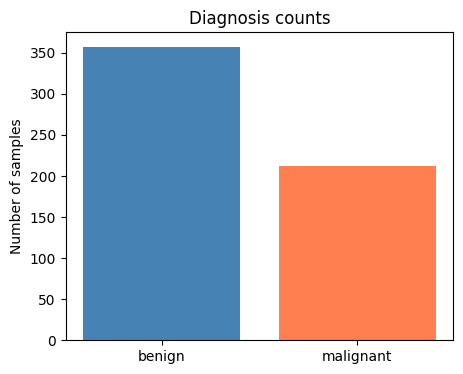

In [56]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(diagnosis_counts.index, diagnosis_counts.values, color=['steelblue', 'coral'])
ax.set_title('Diagnosis counts')
ax.set_ylabel('Number of samples')
plt.show()

In [57]:
diagnosis_pct = df['diagnosis'].value_counts(normalize=True) * 100
print(f"Benign: {diagnosis_pct['benign']:.1f}%  |  Malignant: {diagnosis_pct['malignant']:.1f}%")

Benign: 62.7%  |  Malignant: 37.3%


About **63%** benign and **37%** malignant. The classes are imbalanced, but not drastically so.

Why does this matter? If a model just predicted "benign" for every sample, it would be right ~63% of the time. That sounds ok, but it would **miss every single cancer case** — which is the whole point of the exercise!

The good news: most scikit-learn classifiers let us account for this with a single parameter — `class_weight='balanced'`. This tells the model to penalise mistakes on the minority class (malignant) more heavily, so it doesn't just ignore them. We'll use this when we build our model.

## Train/test split

We need to split our data into two sets:

- **Training set (80%)** — the model learns from this data.
- **Test set (20%)** — held back to evaluate the model on data it has never seen.

Why? If we test the model on the same data it trained on, we have no idea whether it has actually learned useful patterns or just memorised the answers.

First, let's separate our **features** (X) from our **label** (y).

In [58]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

print(f"Features: {X.shape}")
print(f"Labels:   {y.shape}")

Features: (569, 30)
Labels:   (569,)


Now let's split. We use `random_state=42` so the split is reproducible, and `stratify=y` to ensure both sets keep the same ratio of malignant vs. benign samples.

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 455 samples
Test set:     114 samples


## Feature scaling

Take a look at our features. `mean area` might be in the hundreds, while `mean smoothness` is a tiny decimal. These are on completely different scales.

Why is this a problem? Many ML algorithms treat all numbers equally. If one feature has values in the hundreds and another has values like 0.05, the model might assume the big-number feature is more important — just because the numbers are bigger. That's not what we want.

**Scaling** fixes this by putting all features on a similar range. We'll use `StandardScaler`, which transforms each feature so that it has a **mean of 0** and a **standard deviation of 1**. In plain English: it centres everything around zero and makes the spread roughly the same.

We `fit` the scaler on the training data (to learn the mean and spread of each feature) and then `transform` both sets.

In [60]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[X_train.columns] = scaler.fit_transform(X_train)
X_test[X_test.columns] = scaler.transform(X_test)

X_train.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
10,0.518559,0.891826,0.424632,0.383925,-0.974744,-0.689772,-0.688586,-0.398175,-1.039155,-0.825056,...,0.579798,1.313242,0.466908,0.445983,-0.596155,-0.634722,-0.610227,-0.235744,0.054566,0.021837
170,-0.516364,-1.639710,-0.541349,-0.542961,0.476219,-0.631834,-0.604281,-0.303075,0.521543,-0.454523,...,-0.582459,-1.690291,-0.611934,-0.587014,0.273582,-0.814844,-0.712666,-0.323208,-0.137576,-0.904402
407,-0.368118,0.455515,-0.388250,-0.402970,-1.432979,-0.383927,-0.342175,-0.765459,-0.850857,-0.226171,...,-0.398622,0.181977,-0.475431,-0.420778,-1.622785,-0.391399,-0.431313,-0.890825,-0.675893,-0.144016
430,0.205285,0.726168,0.400330,0.070612,0.243253,2.203585,2.256094,1.213233,0.818474,0.899791,...,-0.000309,0.274191,0.513776,-0.099482,0.418538,2.865970,2.958619,1.977064,-0.075646,1.728848
27,1.243005,0.194195,1.210377,1.206652,-0.111442,0.051348,0.732962,0.713767,-0.427187,-0.822184,...,1.012835,0.223144,0.938517,0.880910,0.073201,-0.277006,0.327775,0.501859,-0.909322,-0.546249


The values now hover around 0, with positive meaning "above average" and negative meaning "below average". All features are on the same footing — ready for training.

## Training the model

Our data is clean and scaled. Time to train a model.

We'll use **Logistic Regression** — a solid starting point for binary classification. Despite the name, it's a classification algorithm, not a regression one. It outputs a probability (0 to 1) that a tumour is malignant.

Remember the class imbalance from earlier? We'll pass `class_weight='balanced'` so the model pays extra attention to malignant cases.

In [61]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


That's it — two lines. scikit-learn handles all the maths behind the scenes. Let's try it out on a few samples from the test set.

In [62]:
sample = X_test.head(5)
predictions = model.predict(sample)
actual = y_test.head(5)

pd.DataFrame({
    'Predicted': predictions,
    'Actual': actual.values
})

,Predicted,Actual
0,benign,benign
1,malignant,malignant
2,benign,benign
3,malignant,malignant
4,malignant,benign


Let's check the overall accuracy across the entire test set.

In [63]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.1%}")

Accuracy: 97.4%


Accuracy is a useful starting point, but it doesn't tell the full story — especially with imbalanced classes. For a medical model like this, we'd really want to know: *how many malignant cases did we miss?* We'll explore more detailed evaluation metrics like **precision**, **recall**, and **confusion matrices** in an upcoming lesson.

## Logging to an experiment tracker

In a full deployment workflow, you'd log this run to an experiment tracker so it's reproducible. Here's what that would look like with **MLflow** (which you used in Module 3.2):

In [ ]:
# import mlflow
# mlflow.set_experiment("breast-cancer-classifier")
#
# with mlflow.start_run():
#     mlflow.log_param("model", "LogisticRegression")
#     mlflow.log_param("class_weight", "balanced")
#     mlflow.log_metric("accuracy", accuracy)
#
#     # Log class distribution so you can remember why 'balanced' was chosen
#     mlflow.log_metric("pct_benign", diagnosis_pct['benign'])
#     mlflow.log_metric("pct_malignant", diagnosis_pct['malignant'])
#
#     mlflow.log_artifact("./model.joblib")
#     mlflow.log_artifact("./scaler.joblib")

Or you can use **Weights & Biases (WandB)**, which we introduced earlier. It works the same way conceptually — you log parameters, metrics, and artefacts against a run — but it's cloud-hosted, so there's nothing to spin up. (You'll need a free WandB account if you don't already have one.)

In [ ]:
# import wandb
# wandb.init(project="breast-cancer-classifier")
# wandb.config.update({
#     "model": "LogisticRegression",
#     "class_weight": "balanced",
#     "max_iter": 1000,
#     "pct_benign": diagnosis_pct['benign'],
#     "pct_malignant": diagnosis_pct['malignant']
# })
# wandb.log({"accuracy": accuracy})
# wandb.save("./model.joblib")
# wandb.save("./scaler.joblib")
# wandb.finish()

**Going further:** You can uncomment and test the MLOps logging code snippets above as a stretch exercise.

## Saving to disk

Let's save the model and scaler to disk so we can load them up later without retraining.

In [64]:
joblib.dump(model, './model.joblib')
joblib.dump(scaler, './scaler.joblib')

print("Saved: model.joblib, scaler.joblib")

Saved: model.joblib, scaler.joblib


We save both artefacts because to make a prediction on new data, we need to scale it with the same scaler before passing it to the model. Without the scaler, the model would receive data on a different scale to what it was trained on — and the predictions would be nonsense.

That's it! We've gone from a CSV file to a trained model saved to disk. In the next lesson, we'll look at how to properly evaluate how good this model really is.